# 00 · Data overview

What is on disk, in which convention, and what each dataset looks like.
Run this first on a new machine: the `on_disk` column tells you whether the
data root is set correctly.

**Conventions (enforced by `fmmpaper.io`)**
- `Z` is complex, raw lock-in volts for checkpoints (× InvOLS / 32 → metres).
- Phase is in the model convention (falls through resonance). Pre-2026-09-17 files are Igor-raw and are conjugated on load.
- Positions are stage µm; distance from clamp = `x_um − probe.clamp_offset_um`.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : C:\Users\lz1\Documents\Github\ActiveModeMap_repo\ActiveModeMap\paper_analysis
data_root: D:\ActiveModeMap  (ok)
amm_repo : C:\Users\lz1\Documents\Github\ActiveModeMap_repo\ActiveModeMap  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (ok)
fmm_code_zip: C:\Users\lz1\Documents\Github\ActiveModeMap_repo\Manuscript_FMM\FMM_analysis_code.zip  (ok)


## Registry: probes and datasets

In [2]:
pd.DataFrame([dict(key=p.key, name=p.name, k_N_per_m=p.k_N_per_m, L_um=p.L_um,
                   clamp_offset_um=p.clamp_offset_um,
                   bands_kHz={k: tuple(round(v/1e3) for v in b) for k, b in p.bands_Hz.items()})
              for p in F.registry.PROBES.values()])

,key,name,k_N_per_m,L_um,clamp_offset_um,bands_kHz
0,scmpitB,"SCM-PIT-B (Nanosensors SCM-PIT, Pt-Ir)",1.697,225.9,6.1,"{'CR1': (255, 330), 'CR2': (840, 960), 'CR3': ..."
1,pppcontau,PPP-CONTAu (soft Au-coated contact lever),0.406,450.0,0.0,"{'CR1': (50, 80), 'CR2': (180, 220), 'CR3': (3..."
2,scmpitA,"SCM-PIT-A (SCM-PIT, Multi75G nominal geometry)",2.387,225.0,0.0,"{'CR1': (250, 400), 'CR2': (840, 960)}"
3,p0,P0 (first AL-demo probe),3.630,225.0,0.0,"{'CR1': (330, 450), 'CR2': (1050, 1300)}"


In [3]:
avail = F.available()
avail

,key,probe,kind,figure,on_disk,description
0,scmpitB_r2_preflight,scmpitB,json,6,True,"R2 pre-flight: span, CR1-3, InvOLS(x)"
1,scmpitB_r2_bias,scmpitB,series,"6, 7",True,"R2 two-domain bias survey, 8 pos x 7 V x 2 spo..."
2,scmpitB_r2_wb_fast,scmpitB,series,4,True,"R2 live wideband N=8, 0 V"
3,scmpitB_r2_wb_valid,scmpitB,series,4,True,"R2 held-out validation, 7 never-visited midpoints"
4,scmpitB_r2_dense,scmpitB,series,"1, 3, 5",True,"R2 dense map, 161 pos at 1 um (192 min)"
5,scmpitB_r2_load_extension,scmpitB,series,SI,True,R2 load ladder 50-500 nN x 8 pos (one checkpoi...
6,scmpitB_r2_bias_vs_load,scmpitB,series,SI,True,R2 bias series at 100/300/500 nN (monotonic sw...
7,scmpitB_r2_ac_series,scmpitB,series,"7, SI",True,"R2 17-pt AC series 2 mV-2 V at position A, bot..."
8,scmpitB_r2_images,scmpitB,json,7,True,"R2 quantitative CR1/QS imaging, positions A an..."
9,scmpitB_r2_s3,scmpitB,json,6,True,"R2 reduced transfer function: P_qs, P_CR1, E, ..."


## Shape, span and conditions of every series on disk

In [4]:
rows = []
for key in avail.query("on_disk and kind != 'json'").key:
    try:
        s = F.load(key)
    except Exception as e:
        rows.append(dict(key=key, error=str(e))); continue
    if isinstance(s, dict):              # folder datasets (load ladder, AC series)
        rows.append(dict(key=key, shape=f"{len(s)} checkpoints", conditions=list(s)[:6]))
        continue
    rows.append(dict(key=key, shape=s.Z.shape, x_span=f"{s.x_um.min():.1f}-{s.x_um.max():.1f}",
                     f_kHz=f"{s.freq_Hz.min()/1e3:.1f}-{s.freq_Hz.max()/1e3:.0f}",
                     n_freq=s.freq_Hz.size,
                     phase_file=s.meta['phase_convention_file'],
                     conjugated=s.meta['phase_converted'],
                     conditions={c: sorted(s.conditions[c].dropna().unique().tolist())
                                 for c in s.conditions.columns}))
pd.DataFrame(rows)

,key,shape,x_span,f_kHz,n_freq,phase_file,conjugated,conditions
0,scmpitB_r2_bias,"(14, 8, 58816)",72.0-232.0,0.1-2000,58816.0,model,False,"{'bias_V': [-9.0, -6.0, -3.0, 0.0, 3.0, 6.0, 9..."
1,scmpitB_r2_wb_fast,"(1, 8, 58816)",72.0-232.0,0.1-2000,58816.0,model,False,"{'bias_V': [0.0], 'load_nN': [500.0], 'spot': ..."
2,scmpitB_r2_wb_valid,"(1, 7, 58816)",83.4-220.6,0.1-2000,58816.0,model,False,"{'bias_V': [0.0], 'load_nN': [500.0], 'spot': ..."
3,scmpitB_r2_dense,"(1, 161, 58816)",72.0-232.0,0.1-2000,58816.0,model,False,"{'bias_V': [0.0], 'load_nN': [500.0], 'spot': ..."
4,scmpitB_r2_load_extension,5 checkpoints,NaN,NaN,NaN,NaN,NaN,"[50.0, 100.0, 200.0, 350.0, 500.0]"
5,scmpitB_r2_bias_vs_load,3 checkpoints,NaN,NaN,NaN,NaN,NaN,"[100.0, 300.0, 500.0]"
6,scmpitB_r2_ac_series,17 checkpoints,NaN,NaN,NaN,NaN,NaN,"[ac_series_A_vac0002.00mV_checkpoint, ac_serie..."
7,scmpitB_r1_bias,"(14, 8, 58816)",52.0-232.0,0.1-2000,58816.0,model,False,"{'bias_V': [-9.0, -6.0, -3.0, 0.0, 3.0, 6.0, 9..."
8,scmpitB_r1_wb_fast,"(1, 8, 58816)",52.0-232.0,0.1-2000,58816.0,model,False,"{'bias_V': [0.0], 'load_nN': [500.0], 'spot': ..."
9,scmpitB_r1_wb_valid,"(1, 7, 58816)",64.8-219.2,0.1-2000,58816.0,model,False,"{'bias_V': [0.0], 'load_nN': [500.0], 'spot': ..."


## Phase-convention check
After loading, the phase through the CR1 peak should *fall* (negative slope) for every dataset.
A positive number means a file was mislabelled and phase-sensitive results from it are wrong.

In [5]:
chk = []
for key in avail.query("on_disk and kind != 'json'").key:
    s = F.load(key)
    if isinstance(s, dict):
        continue
    band = s.probe.bands_Hz['CR1']
    j = s.Z.shape[1] // 2
    chk.append(dict(key=key, x_um=s.x_um[j],
                    dphase_deg=io.phase_slope_through_peak(s.freq_Hz, s.Z[0, j], band)))
pd.DataFrame(chk)

,key,x_um,dphase_deg
0,scmpitB_r2_bias,163.4,-92.666398
1,scmpitB_r2_wb_fast,163.4,-95.030350
2,scmpitB_r2_wb_valid,152.0,-90.263224
3,scmpitB_r2_dense,152.0,-93.295079
4,scmpitB_r1_bias,154.9,-91.020021
5,scmpitB_r1_wb_fast,154.9,-93.039796
6,scmpitB_r1_wb_valid,142.0,-92.246620
7,scmpitB_r1_dense,142.0,-94.272160
8,ppp_dense_1um,273.0,-100.876052
9,ppp_sparse_rank6,320.0,-102.522843


## Quick-look maps: one per probe

[WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/00_quicklook_three_probes.png'),
 WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/00_quicklook_three_probes.pdf')]

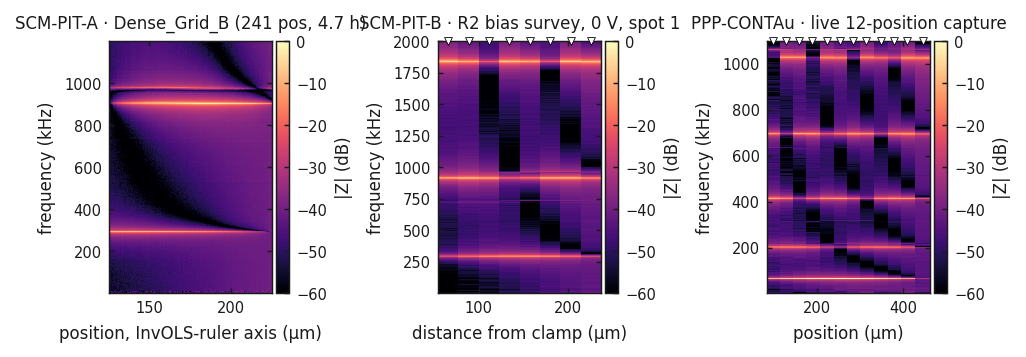

In [6]:
fig, axs = fp.figure("double", aspect=0.36, ncols=3)
g = F.load("scmpitA_gridB")
fp.map_db(axs[0], g.meta['x_true_um'], g.freq_Hz, g.Z[0], fmax=1200)
axs[0].set_title("SCM-PIT-A · Dense_Grid_B (241 pos, 4.7 h)")
axs[0].set_xlabel("position, InvOLS-ruler axis (µm)")

s = F.load("scmpitB_r2_bias"); i0 = s.where(bias_V=0, spot=1)[0]
fp.map_db(axs[1], s.x_clamp_um, s.freq_Hz, s.Z[i0], fmax=2000)
fp.mark_positions(axs[1], s.x_clamp_um)
axs[1].set_title("SCM-PIT-B · R2 bias survey, 0 V, spot 1")
axs[1].set_xlabel("distance from clamp (µm)")

p = F.load("ppp_wb_fast")
fp.map_db(axs[2], p.x_um, p.freq_Hz, p.Z[0], fmax=1100)
fp.mark_positions(axs[2], p.x_um)
axs[2].set_title("PPP-CONTAu · live 12-position capture")
fig.tight_layout()
fp.save(fig, "00_quicklook_three_probes")

## InvOLS position ruler (SCM-PIT-A)
Draft Sec. S1: x_true ≈ 0.843 x_cmd + 37.5 µm with ~0.5 µm rms. Reproduced here from the log.

axis fit (slope, offset): [ 0.8431 37.4823]  rms 0.522 um


[WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/00_gridB_axis.png'),
 WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/00_gridB_axis.pdf')]

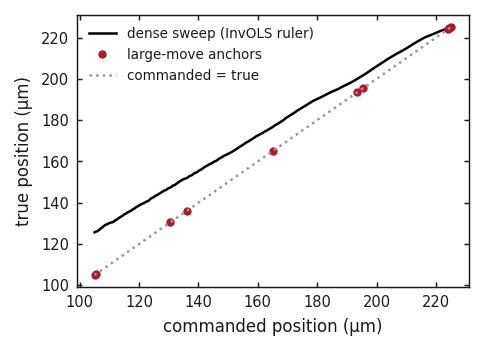

In [7]:
print("axis fit (slope, offset):", np.round(g.meta['axis_fit'], 4), " rms", round(g.meta['axis_rms_um'], 3), "um")
fig, ax = fp.figure("single", aspect=0.7)
ax.plot(g.x_um, g.meta['x_true_um'], 'k-', label='dense sweep (InvOLS ruler)')
ax.plot(g.meta['anchors_x_um'], g.meta['anchors_x_um'], 'o', color=fp.C['ebgp'], ms=3, label='large-move anchors')
ax.plot(g.x_um, g.x_um, ':', color='0.6', label='commanded = true')
ax.set_xlabel("commanded position (µm)"); ax.set_ylabel("true position (µm)"); ax.legend()
fp.save(fig, "00_gridB_axis")